# Tasks 3 and 4 - the U-Net and the full pipeline

The network is the small U-Net from lab 4, unchanged. It has 3 encoder levels, a bottleneck
and 3 decoder levels, 483,153 parameters. The lab ran it at 128x128 and these images are
256x256, which is fine because there is no fully connected layer.

Run `python3 -m src.train` first if outputs/models is empty.


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import json
pd.set_option('display.width', 130)

from src.train import (load_model, plot_history, prediction_panel, compare_with_classical,
                       robustness_table, compare_normalisation)
from src.unet import UNet, count_parameters

model = load_model()
print('parameters:', f'{count_parameters(model):,}')


parameters: 483,153


## Training

40 epochs, Adam, learning rate 1e-3, batch size 8, BCE + Dice. I keep the weights from the
epoch with the best validation Dice, not the last epoch. Training takes about 2 minutes.


best val dice: 0.9971


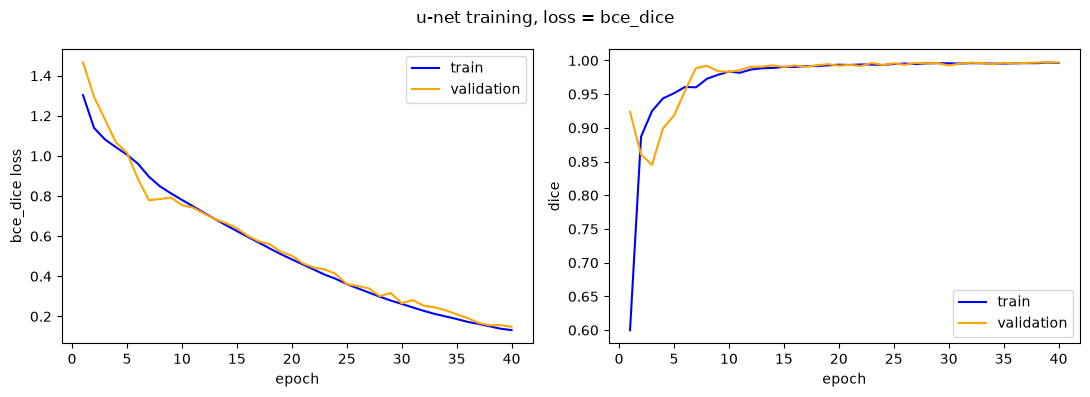

In [2]:
history = pd.read_csv('../outputs/csv/history_bce_dice.csv')
fig = plot_history(history)
print('best val dice:', history.val_dice.max().round(4))


The validation curve follows the training curve the whole way, so with 80 images and only
flips and rotations as augmentation there is no overfitting. Dice stops improving around
epoch 15, so 40 epochs is more than needed.


## Input, ground truth, prediction


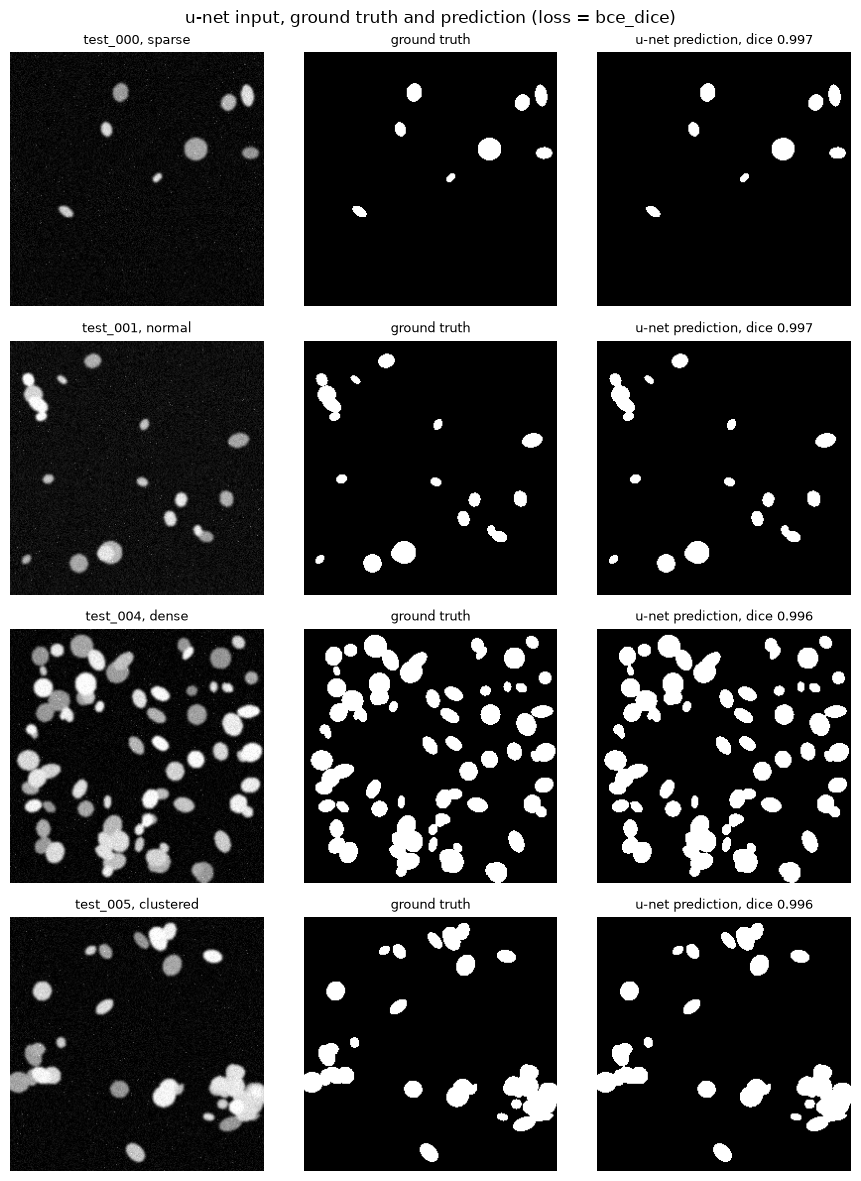

In [3]:
fig = prediction_panel(model, 'test')


In the clustered row the touching nuclei are one connected blob in the ground truth mask as
well as in the prediction. Dice is still 0.996. This is why the mask can be almost perfect
while the count is wrong by 11.


## Which loss

Three identical networks, same seed, three losses.


--- training with bce ---


--- training with dice ---


--- training with bce_dice ---


,loss,val_dice,test_dice,test_iou,count_MAE
0,bce,0.9971,0.9971,0.9942,2.67
1,dice,0.9964,0.9961,0.9922,2.42
2,bce_dice,0.9971,0.9970,0.9940,2.33


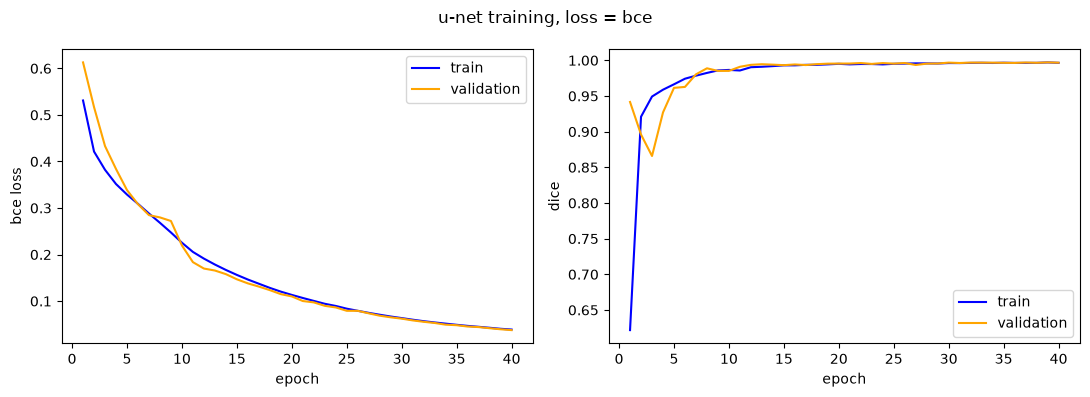

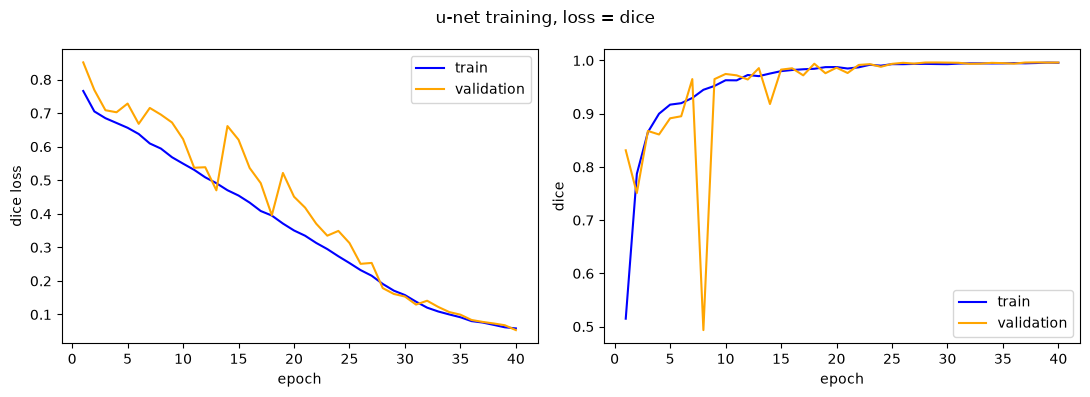

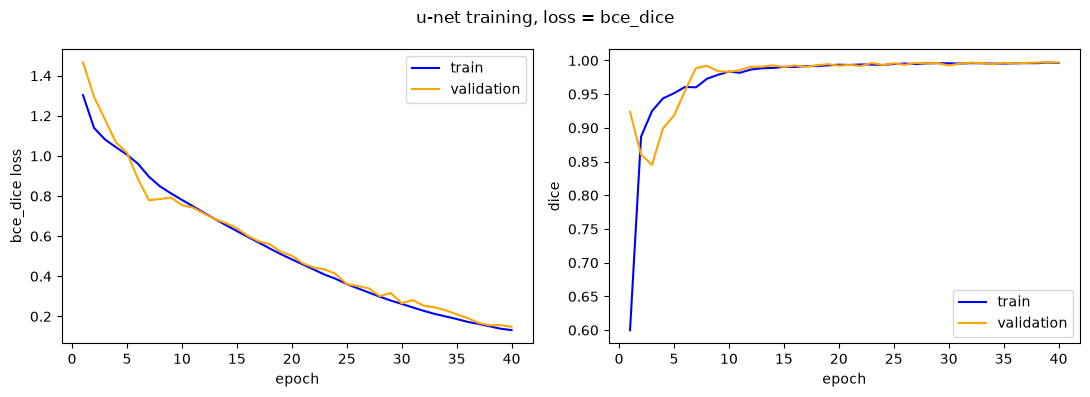

In [4]:
from src.train import compare_losses
from config import setting

# trains three networks, about four minutes
ablation = compare_losses()
ablation.to_csv(setting.csv_dir / 'loss_ablation.csv', index=False)
ablation


The three are within 0.0007 Dice of each other. The lab notes say a gap under about 0.01
Dice on 20 validation images is seed noise, so this says the three losses are the same here,
not that one is better. I only ran one seed anyway.

Dice loss is meant to help when the classes are unbalanced. Here the foreground is 2 to 22%
of the image and the histogram is clean, so BCE on its own already gets there.


## U-Net against Otsu

Same evaluation, same watershed with the same settings for counting. The only difference is
where the mask comes from.


In [5]:
compare_with_classical(model)


,dice_otsu,dice_unet,count_error_otsu,count_error_unet
density,,,,
clustered,0.975,0.996,-8.500,-8.000
dense,0.976,0.996,-4.000,-1.500
normal,0.979,0.997,2.500,0.833
sparse,0.975,0.998,1.500,1.000
all images,0.977,0.997,-0.583,-1.000


The U-Net is much better at segmentation: Dice error drops from 2.3% to 0.3%. Counting
improves too, but on clustered images it barely moves, -8.5 to -8.0. Both routes use the
same watershed, and if two nuclei touch, the mask has no information that could separate
them. The bottleneck moved from segmentation to instance separation.


# Task 4 - the whole pipeline

U-Net mask, then regionprops, then a JSON record and a paragraph from the model.
Run `python3 -m src.pipeline` to make these files.


In [6]:
records = pd.read_csv('../outputs/csv/pipeline_test_unet.csv')
print('records with a number copied wrongly:', (records.number_issues.notna()).sum(), '/ 12')
records[['image_id', 'n_objects', 'mean_area', 'density_llm', 'density_rule', 'density_true']]


records with a number copied wrongly: 0 / 12


,image_id,n_objects,mean_area,density_llm,density_rule,density_true
0,test_000,10,152.7,normal,sparse,sparse
1,test_001,19,147.7,normal,normal,normal
2,test_002,34,168.0,normal,normal,normal
3,test_003,22,175.7,normal,normal,normal
4,test_004,72,196.7,normal,dense,dense
5,test_005,32,203.7,normal,normal,clustered
6,test_006,8,198.0,normal,sparse,sparse
7,test_007,29,163.5,normal,normal,normal
8,test_008,30,184.2,normal,normal,normal
9,test_009,24,156.1,normal,normal,normal


In [7]:
example = json.load(open('../outputs/json/pipeline/unet_test_005.json'))
print(example['summary_sent'])
print()
print(json.dumps(example['record'], indent=2))


Image: test_005 (256 x 256 pixels)
Objects detected: 32
Total area covered by objects: 9.9% of the image
Object area in pixels: mean 204, median 184, min 40, max 735, std 140
Eccentricity: mean 0.69, std 0.21 (0 is a circle, 1 is a line)
Solidity: mean 0.95 (1 means a convex, unbroken shape)
Mean intensity inside objects: 0.745 on a 0 to 1 scale
Median distance to the nearest other object: 15.0 pixels

{
  "image_id": "test_005",
  "n_objects": 32,
  "mean_area": 204,
  "density_class": "normal",
  "quality_flag": "ok",
  "narrative": "The image test_005 contains 32 objects, with a mean area of 204 pixels. The objects are relatively evenly spaced, with a median distance to the nearest other object of 15.0 pixels, indicating a normal density. The objects are also mostly convex and unbroken, with a mean solidity of 0.95, suggesting a high level of quality in the segmentation."
}


## The model cannot apply the bands

The prompt gives the density bands as numbers. The model still answers `normal` for every
image, including one with 78 objects where the band says dense. So I also wrote the same
bands as four lines of Python and compared.


In [8]:
from src.pipeline import check_density_rule, ask_llm_to_apply_bands

print('llm  correct:', (records.density_llm == records.density_true).sum(), '/ 12')
print('rule correct:', (records.density_rule == records.density_true).sum(), '/ 12')


llm  correct: 6 / 12
rule correct: 10 / 12


In [9]:
bands = ask_llm_to_apply_bands()
bands.to_csv('../outputs/csv/llm_band_lookup.csv', index=False)
bands


,n_objects,nearest_neighbour,expected,llm_answer,rule_answer
0,78,15.2,dense,normal,dense
1,8,33.9,sparse,normal,sparse
2,24,22.0,normal,normal,normal
3,32,10.1,clustered,normal,clustered


Four sets of numbers, the bands written out in the prompt, nothing else to do but look them
up. The model gets one right. The four lines of Python get all four.

The rule agrees with the metadata label on 98 of the 100 train and val images:


In [10]:
rule_df, accuracy = check_density_rule()
print('rule accuracy on train + val:', accuracy)
rule_df[rule_df.true != rule_df.predicted]


rule accuracy on train + val: 0.98


,image_id,true,predicted
11,train_011,clustered,normal
29,train_029,clustered,normal


On the test images the rule gets 10 of 12. The two it misses are test_005 and test_011, and
they fail for different reasons. For test_005 the true nearest-neighbour distance is 10.5 px,
which is below the 12 px threshold, but after watershed merges the touching nuclei the
measured distance becomes 15.0 px. So a segmentation problem turns into a wrong label in the
final sentence. For test_011 the true distance is already 15.9 px, so the rule itself cannot
separate that case.


## Extension - what happens when the image is damaged

The four corrupted test images through both segmenters, scored against the mask of the clean
original.


In [11]:
robust = robustness_table(model)
robust.to_csv('../outputs/csv/robustness_otsu_vs_unet.csv', index=False)
robust


,base_id,variant,dice_otsu,dice_unet
0,test_000,clean,0.9813,0.9971
1,test_000,blur,0.6710,0.6785
3,test_000,lowcontrast,0.9714,0.0457
4,test_004,clean,0.9795,0.9962
5,test_004,blur,0.7846,0.6546
7,test_004,lowcontrast,0.9798,0.3558


This reverses the result above. On the low contrast images Otsu keeps a Dice around 0.97
while the U-Net drops to 0.046 and marks the whole image as foreground.

Otsu takes its threshold from the histogram of the image it is given, so squeezing the
contrast does not change which pixels end up on either side of it. The U-Net learned
absolute intensity values, because I normalise by dividing by 255 and my augmentation only
flips and rotates. It has never seen an image like that.


In [12]:
compare_normalisation(model)


,image,fixed,per_image
0,test_000_blur,0.6785,0.5317
1,test_000_lowcontrast,0.0457,0.9971
2,test_004_blur,0.6546,0.6363
3,test_004_lowcontrast,0.3558,0.9959


Switching to per-image min-max normalisation at inference brings the low contrast images
back to 0.997 and 0.996, and costs nothing on the clean images. I picked fixed normalisation
so that a contrast change would still be visible in the feature table, which was right for
the measurements and wrong for the network input. The two should not share one setting.


In [13]:
pd.read_csv('../outputs/csv/pipeline_corrupted_unet.csv').drop_duplicates()


,base_id,variant,n_objects,mean_area,area_fraction,dice_vs_clean_truth,density_class,quality_flag
0,test_000,clean,10,152.7,0.0233,0.9971,normal,ok
1,test_000,blur,9,332.0,0.0456,0.6785,normal,ok
3,test_000,lowcontrast,1,65532.0,0.9999,0.0457,sparse,ok
4,test_004,clean,72,196.7,0.2161,0.9962,normal,ok
5,test_004,blur,73,399.1,0.4445,0.6546,normal,ok
7,test_004,lowcontrast,1,65532.0,0.9999,0.3558,sparse,ok


The last thing to note is quality_flag. Every one of these says `ok`, including the row
where the pipeline found a single object of 65532 pixels covering 99.99% of the image. The
numbers that would give it away are in the summary the model was given.
